In [1]:
import sys
import numpy as np
import yaml
import matplotlib.pyplot as plt

sys.path.append("lightecho_modeling_oop/OOP")
import SimulateLEInfPlane
from definitions import CONFIG_PATH_UTILS, CONFIG_PATH_DUST
sys.path.append(CONFIG_PATH_UTILS)
sys.path.append(CONFIG_PATH_DUST)
import var_constants as vc
import fix_constants as fc
import dust_constants as dc
from Source import Source
from LE_img import LEImageAnalytical

In [2]:
%config InlineBackend.figure_format='retina'
plt.style.use('tableau-colorblind10')

# Simulate LE

In [3]:
initi_LE = SimulateLEInfPlane.CalculateLE(file_name='/pscratch/sd/t/taceroc/LE_inj/params_le_for_4026_15_2022_y.yml', 
                                ids=0, args=[False, False])

[False, False] /pscratch/sd/t/taceroc/LE_inj/params_le_for_4026_15_2022_y.yml 0
{'Flmax': 1e+16, 'angles': [0, 360], 'ct': 500, 'd': 52000, 'dt0': 0, 'dz0': 0.06, 'plane_coefficients': [0, 0, 1, 12], 'wave': 0.567, 'loc_to_fits': '4026_15_v2/plane', 'composition': 'both'}
/pscratch/sd/t/taceroc/LE_inj
True
TIME LE elliposid in days 516.8679000000047
TIME of the SN LC respect to peak -16.867900000004738
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
mean of rho 10.623195256669106
half_obs_thickness given by dust 0.013043038898438629
carb values
silicate values
FLUX AFTER SURFACE 1.1672670704566824e-37
size arcsec 26.0 26.0
size img pixels 130 130
OBS TIME 500.0


In [4]:
surface_val = initi_LE.run()

True
TIME LE elliposid in days 484.03120000000496
TIME of the SN LC respect to peak 15.968799999995097
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 5.671489571383294e-16
mean of rho 10.27440762859728
half_obs_thickness given by dust 0.012629057972159633
carb values
silicate values
FLUX AFTER SURFACE 3.129502682881756e-29
Before angle clipping
Len of z values
0
True
TIME LE elliposid in days 465.0108000000037
TIME of the SN LC respect to peak 34.989199999996345
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.116837363414515e-16
mean of rho 10.067217143816785
half_obs_thickness given by dust 0.012382490278160824
carb values
silicate values
FLUX AFTER SURFACE 3.377984816453853e-29
Before angle clipping
Len of z values
0
True

/tmp/ipykernel_1503318/633967256.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(-2.5*np.log10(surface_val)-48.6, origin='lower')


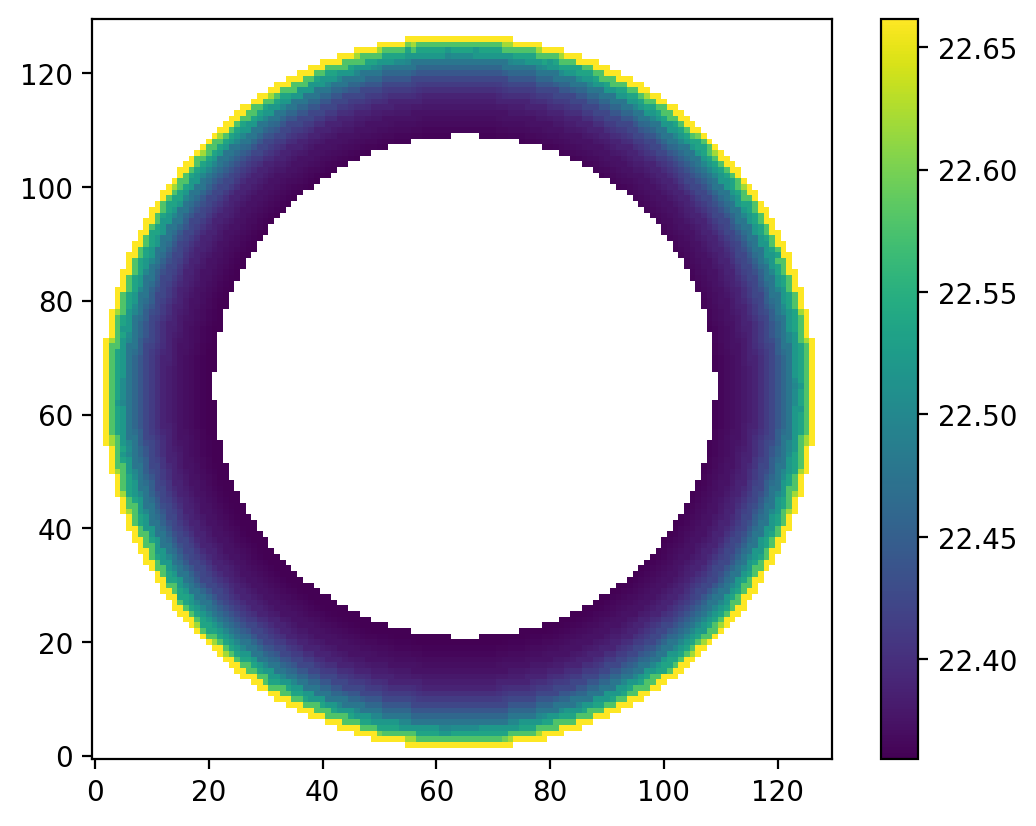

In [5]:
plt.imshow(-2.5*np.log10(surface_val)-48.6, origin='lower')
plt.colorbar()

In [33]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt1 = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][0],
                                                                                                                                          return_LE_plane1source1=True)
cossigma, surface1 = initi_LE.calculate_sb(initi_LE.lc['time'][::40][0], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt1)

le_img1 = LEImageAnalytical(LE_plane1source1_tt1, initi_LE.plane1, surface1, pixel_resolution = 0.2, cmap = 'magma_r')
x_lim_min, x_lim_max = np.min(le_img1.new_xs), np.max(le_img1.new_xs)
y_lim_min, y_lim_max = np.min(le_img1.new_ys), np.max(le_img1.new_ys)

x_tot_arcsec = np.abs(round((x_lim_max - x_lim_min),0))
y_tot_arcsec = np.abs(round((y_lim_max - y_lim_min),0))
print("size arcsec", x_tot_arcsec, y_tot_arcsec)

x_size_img = int(x_tot_arcsec / 0.2)
y_size_img = int(y_tot_arcsec / 0.2)
print("size img pixels", x_size_img, y_size_img)
x_all, y_all = np.meshgrid(np.linspace(x_lim_min, x_lim_max, x_size_img),
    np.linspace(y_lim_min, y_lim_max, y_size_img ))

x_bins = np.linspace(np.nanmin(le_img1.new_xs[0,0,:]), np.nanmax(le_img1.new_xs[0,0,:]), x_size_img)
y_bins = np.linspace(np.nanmin(le_img1.new_ys[0,0,:]), np.nanmax(le_img1.new_ys[0,0,:]), y_size_img)

inds_x1 = np.digitize(le_img1.new_xs[0,0,:], x_bins)
inds_y1 = np.digitize(le_img1.new_ys[0,0,:], y_bins)

matrix_surface = np.ones((x_size_img,y_size_img))*-1

# act_all.extend([le_img1.act])
# bct_all.extend([le_img1.bct])

True
TIME LE elliposid in days 516.8679000000047
TIME of the SN LC respect to peak -16.867900000004738
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
mean of rho 10.623195256669106
half_obs_thickness given by dust 0.013043038898438629
carb values
silicate values
FLUX AFTER SURFACE 1.1672670704566824e-37
size arcsec 26.0 26.0
size img pixels 130 130


/tmp/ipykernel_1580259/261290464.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(-2.5*np.log10(matrix_surface)-48.6)


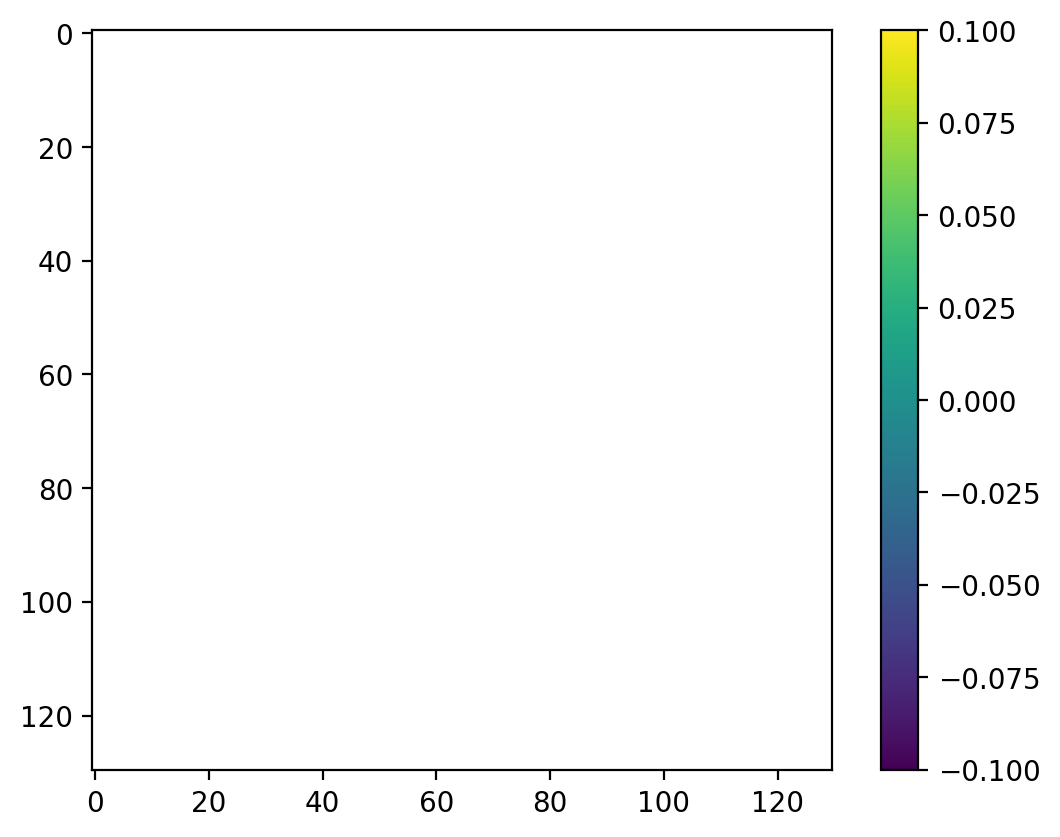

In [34]:
plt.imshow(-2.5*np.log10(matrix_surface)-48.6)
plt.colorbar()

True
TIME LE elliposid in days 509.01220000000467
TIME of the SN LC respect to peak -9.012200000004668
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 4.8202971831514567e-17
mean of rho 10.540733353263933
half_obs_thickness given by dust 0.012945289187165308
carb values
silicate values
FLUX AFTER SURFACE 2.656986883382898e-30


/tmp/ipykernel_1580259/3197798087.py:23: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


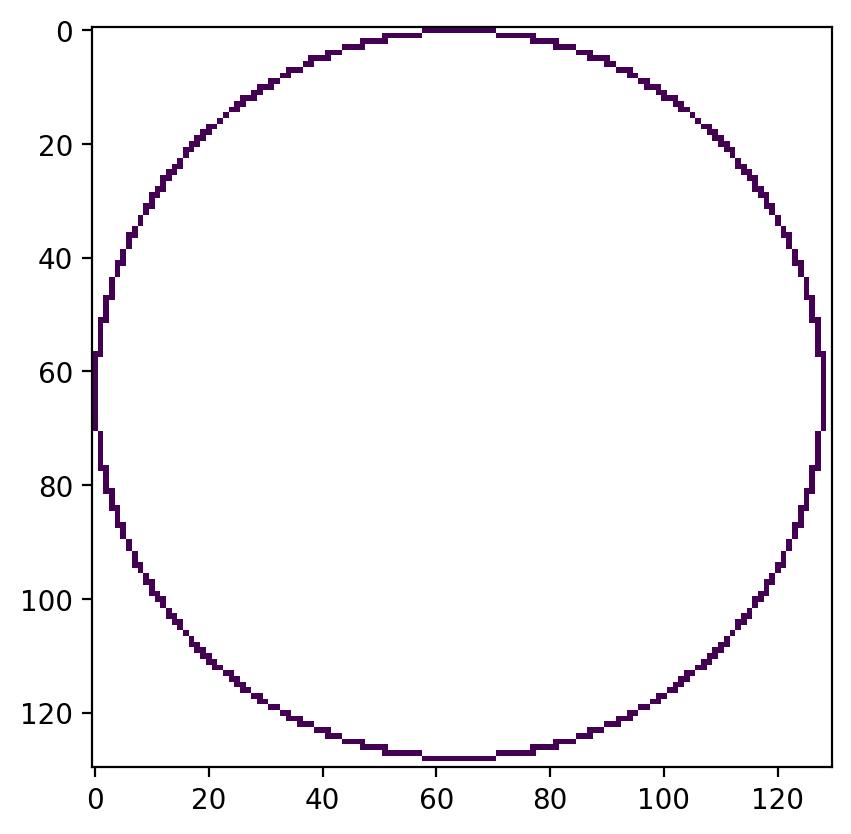

True
TIME LE elliposid in days 496.0540000000037
TIME of the SN LC respect to peak 3.9459999999962743
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 3.843574219610491e-16
mean of rho 10.403379151774853
half_obs_thickness given by dust 0.012782297508764725
carb values
silicate values
FLUX AFTER SURFACE 2.1197798530728145e-29


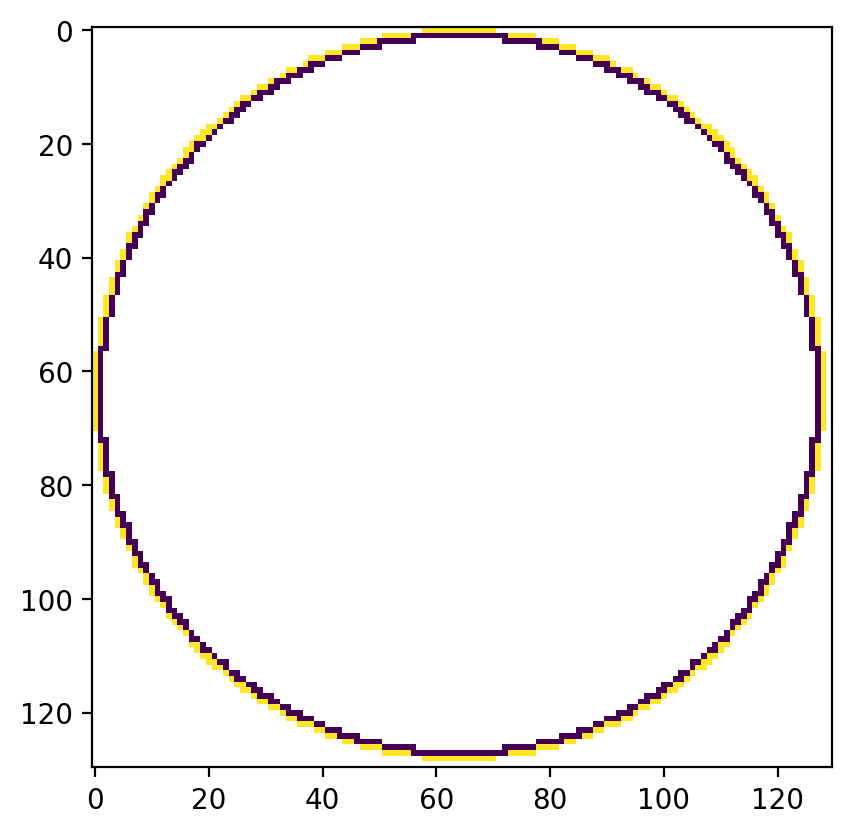

True
TIME LE elliposid in days 484.03120000000496
TIME of the SN LC respect to peak 15.968799999995097
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 5.671489571383294e-16
mean of rho 10.27440762859728
half_obs_thickness given by dust 0.012629057972159633
carb values
silicate values
FLUX AFTER SURFACE 3.129502682881756e-29


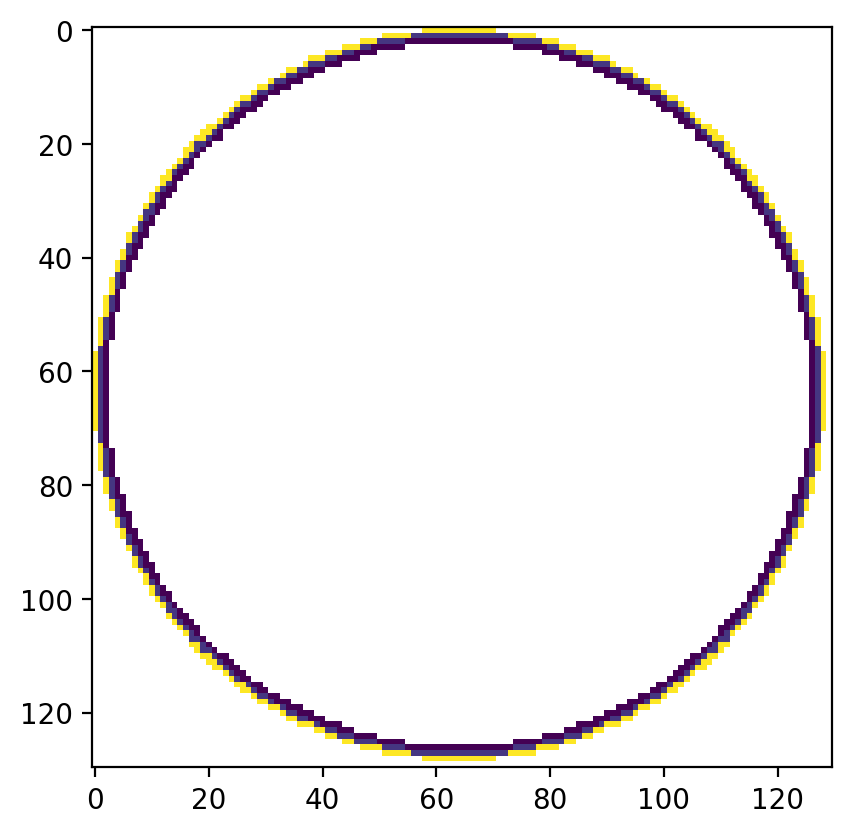

True
TIME LE elliposid in days 465.0108000000037
TIME of the SN LC respect to peak 34.989199999996345
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.116837363414515e-16
mean of rho 10.067217143816785
half_obs_thickness given by dust 0.012382490278160824
carb values
silicate values
FLUX AFTER SURFACE 3.377984816453853e-29


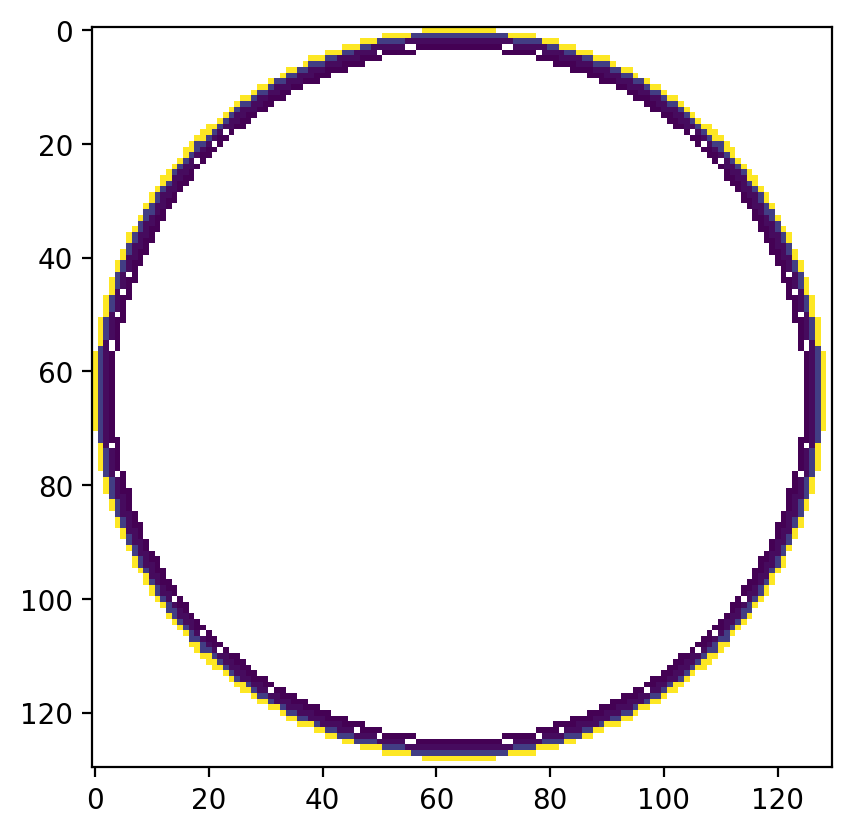

True
TIME LE elliposid in days 454.72430000000173
TIME of the SN LC respect to peak 45.27569999999833
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.358218490763986e-16
mean of rho 9.953482489943898
half_obs_thickness given by dust 0.012246937416470313
carb values
silicate values
FLUX AFTER SURFACE 3.512828996926064e-29


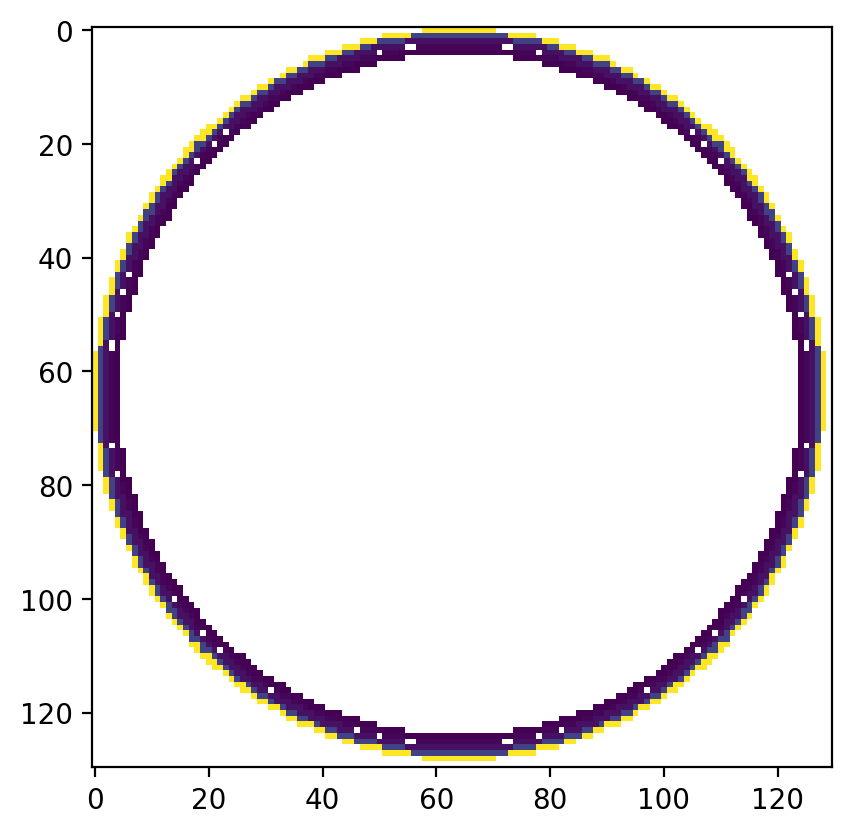

True
TIME LE elliposid in days 444.39400000000023
TIME of the SN LC respect to peak 55.60599999999977
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.449795327198281e-16
mean of rho 9.83802161438025
half_obs_thickness given by dust 0.012109181996708403
carb values
silicate values
FLUX AFTER SURFACE 3.564997245597206e-29


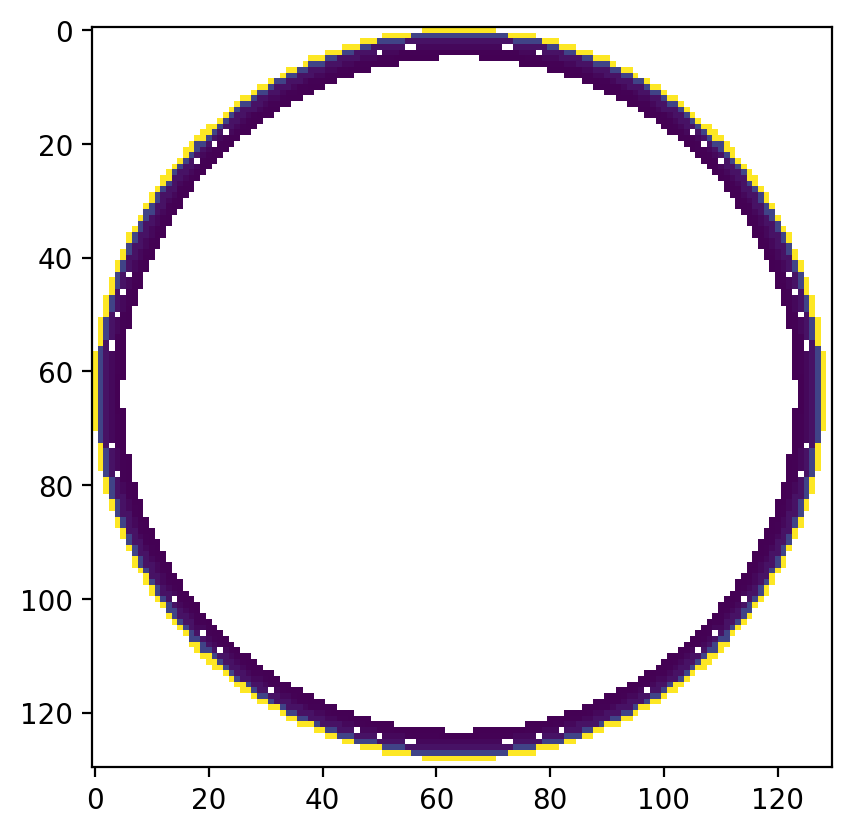

True
TIME LE elliposid in days 422.59590000000026
TIME of the SN LC respect to peak 77.40409999999974
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.694127562418332e-16
mean of rho 9.590099753856416
half_obs_thickness given by dust 0.011812900525819469
carb values
silicate values
FLUX AFTER SURFACE 3.7034975591711996e-29


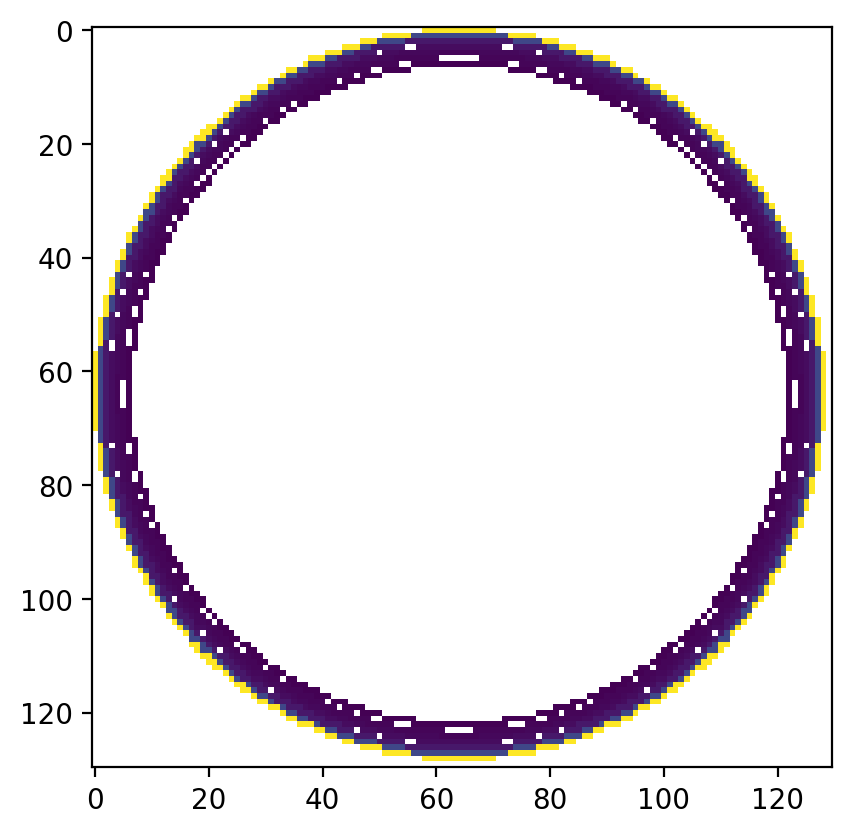

True
TIME LE elliposid in days 381.5740000000006
TIME of the SN LC respect to peak 118.42599999999946
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.029788998199897e-16
mean of rho 9.106309863084974
half_obs_thickness given by dust 0.01123287026232401
carb values
silicate values
FLUX AFTER SURFACE 3.8960388661354027e-29


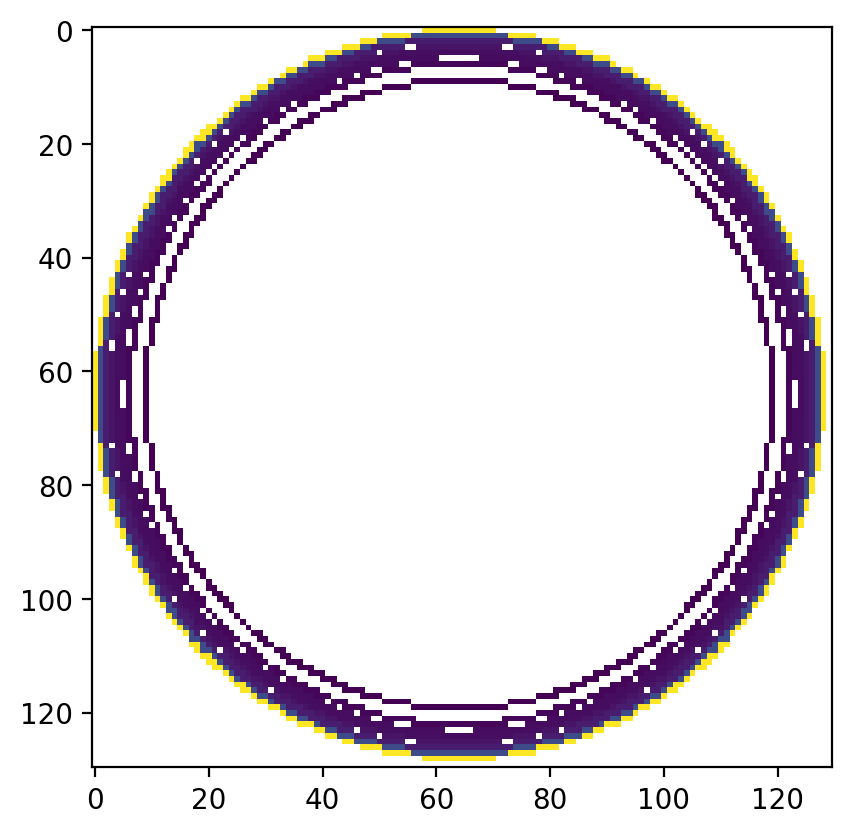

True
TIME LE elliposid in days 338.32289999999927
TIME of the SN LC respect to peak 161.6771000000008
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.240944873261619e-16
mean of rho 8.568289001311765
half_obs_thickness given by dust 0.01058501994242748
carb values
silicate values
FLUX AFTER SURFACE 4.0205193163997523e-29


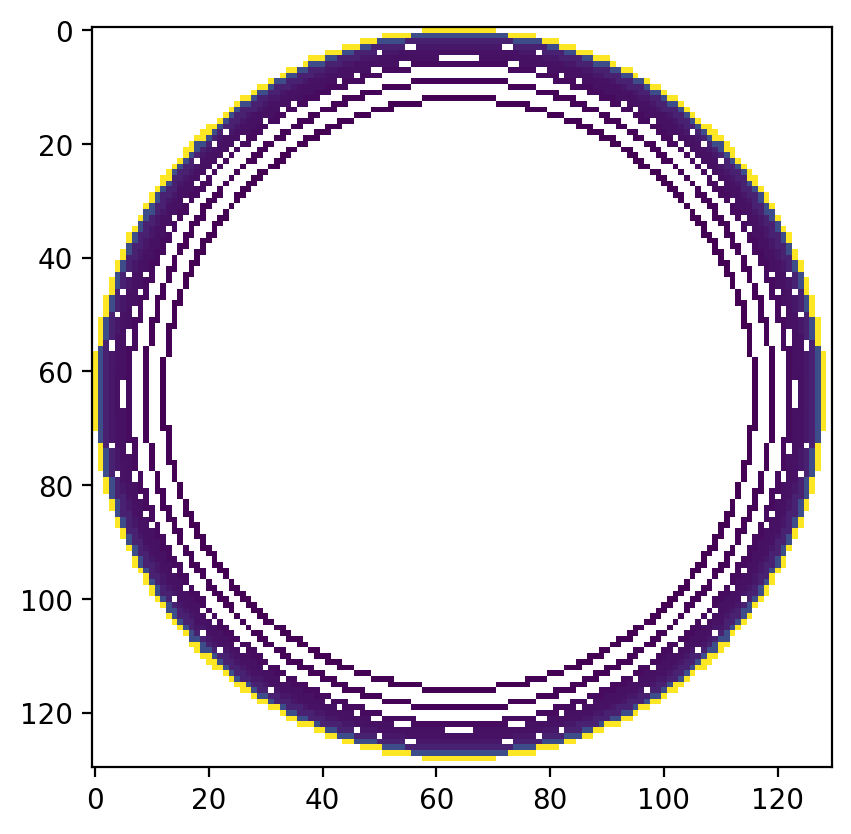

True
TIME LE elliposid in days 303.86409999999887
TIME of the SN LC respect to peak 196.13590000000116
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.331408270166057e-16
mean of rho 8.115384894363958
half_obs_thickness given by dust 0.010037479317584946
carb values
silicate values
FLUX AFTER SURFACE 4.076782574006e-29


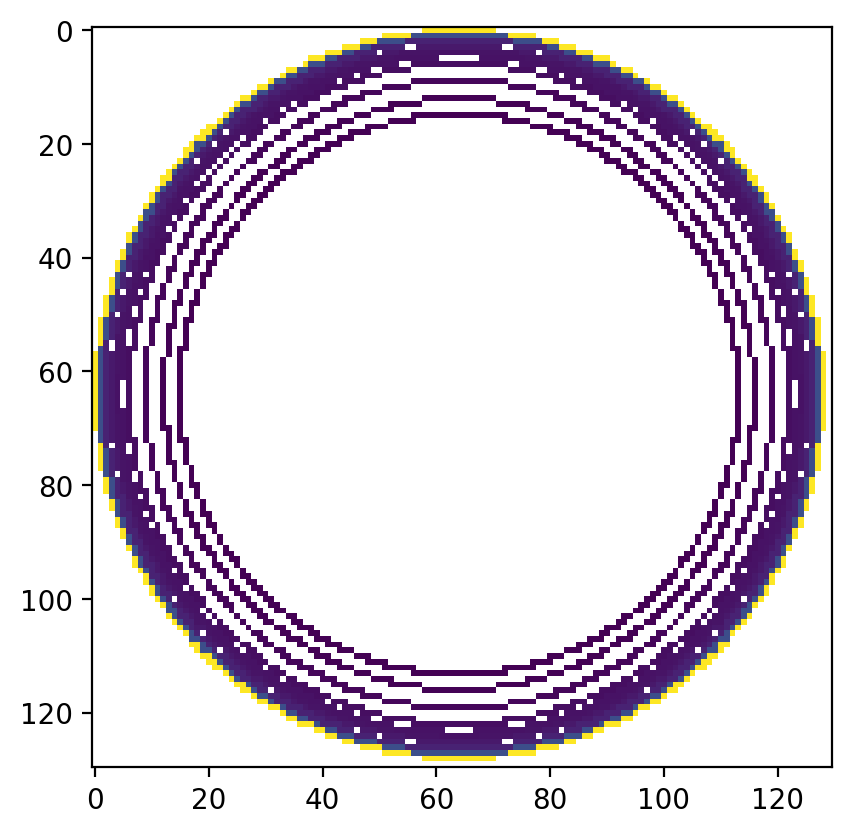

True
TIME LE elliposid in days 244.65469999999917
TIME of the SN LC respect to peak 255.34530000000086
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 7.274455338541214
half_obs_thickness given by dust 0.009015866526658395
carb values
silicate values
FLUX AFTER SURFACE 4.132337204501595e-29


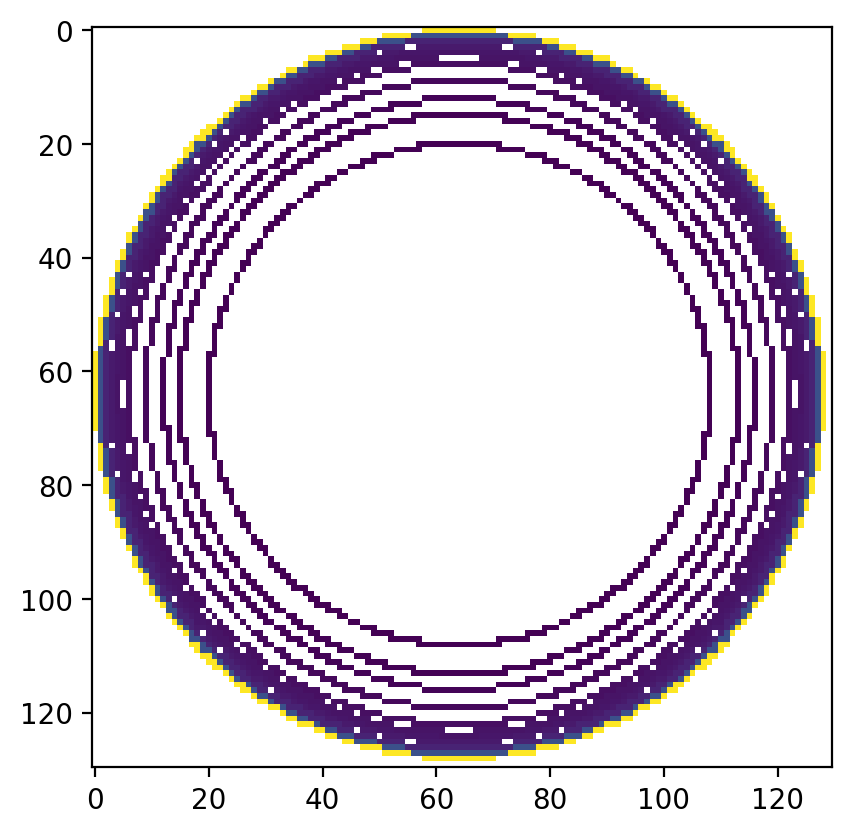

In [13]:

for ij in range(1,12):
    x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][ij],
                                                                                                                                              return_LE_plane1source1=True)
    cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)
    
    le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')
    
    inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
    inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    # x_known.extend(x_bins[inds_x2-1])
    # y_known.extend(y_bins[inds_y2-1])

    # surface_known.extend(surface)

    # act_all.extend([le_img.act])
    # bct_all.extend([le_img.bct])
    
        
    for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
        matrix_surface[xi-1, yj-1] = surface[i]
    fig, ax = plt.subplots()
    ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
    # plt.colorbar()
    plt.show()

/tmp/ipykernel_1580259/261290464.py:1: RuntimeWarning: invalid value encountered in log10
  plt.imshow(-2.5*np.log10(matrix_surface)-48.6)


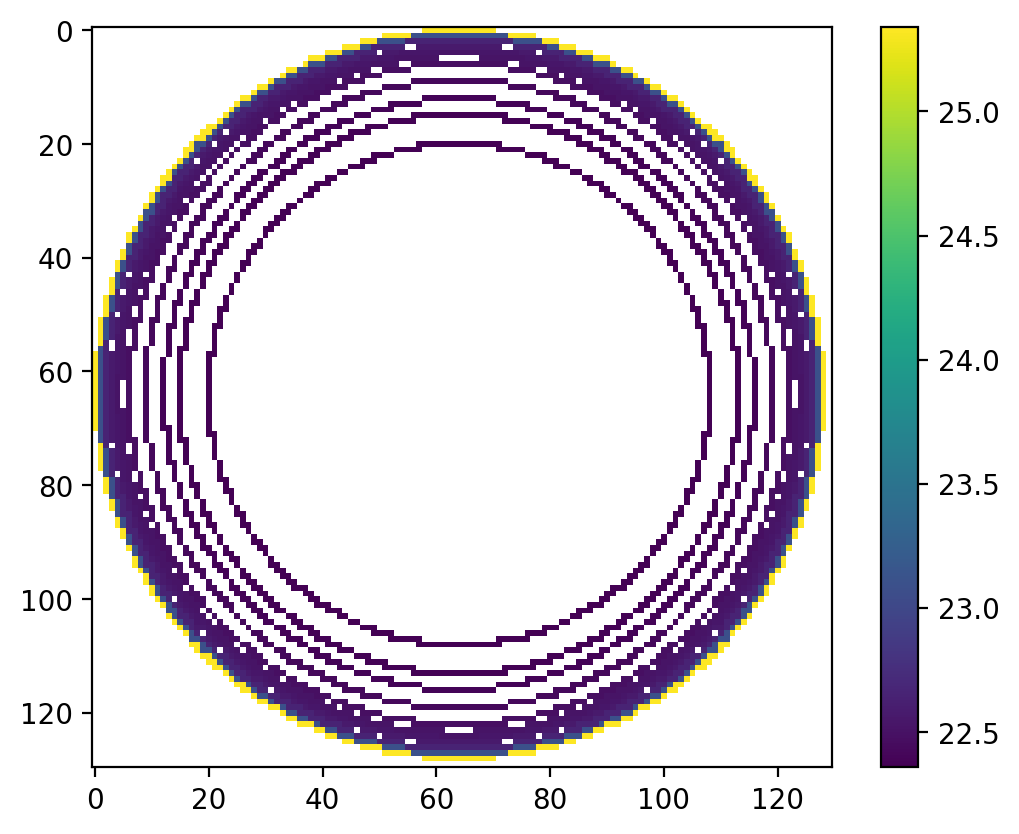

In [14]:
plt.imshow(-2.5*np.log10(matrix_surface)-48.6)
plt.colorbar()

In [9]:
import pandas as pd
file_path = "lightecho_modeling_oop/OOP/LC_sn2011fe.csv"
lc_sn2011fe = pd.read_csv(file_path)

lc = {}
lc['mag'] = lc_sn2011fe['mag'].values - 5
lc['time'] = ((lc_sn2011fe['time'].values) - lc_sn2011fe['time'].min() )


lc['time'] = lc['time'] - lc['time'][lc['mag'] == lc['mag'].min()]

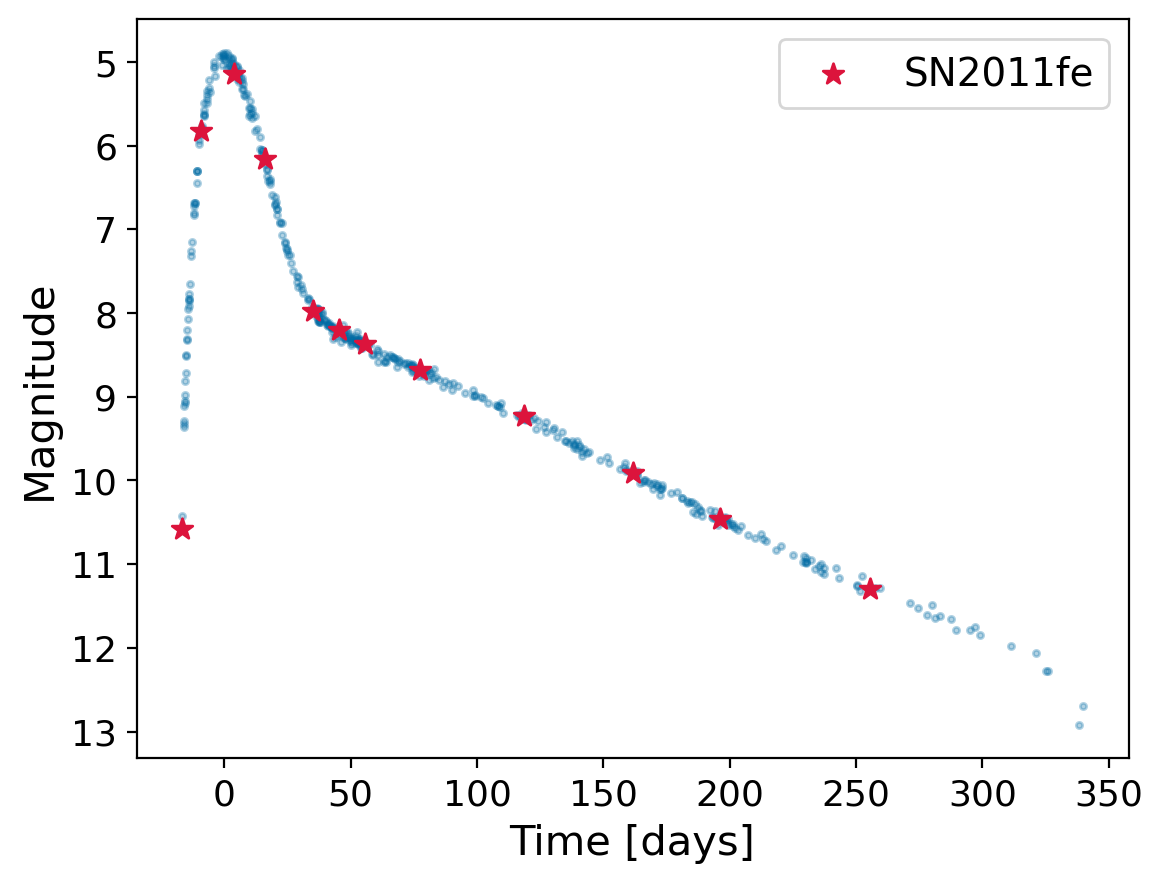

In [10]:
# lc['time'][::40]


fig, ax = plt.subplots()
# ax.scatter(lc['time'], lc['mag'], s=5, label='brighter SN2011fe')
ax.scatter(lc['time'], lc['mag'], s=5, alpha=0.3)
ax.scatter(lc['time'][::40], lc['mag'][::40], s=60, marker="*", c='crimson', label='SN2011fe')

plt.legend(fontsize=14)
ax.invert_yaxis()
ax.set_xlabel('Time [days]', fontsize=15)
ax.set_ylabel('Magnitude', fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

True
TIME LE elliposid in days 509.01220000000467
TIME of the SN LC respect to peak -9.012200000004668
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 10.540733353263933
half_obs_thickness given by dust 0.012945289187165308
carb values
silicate values
FLUX AFTER SURFACE 4.0857668423298757e-29


/tmp/ipykernel_1580259/1939890620.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


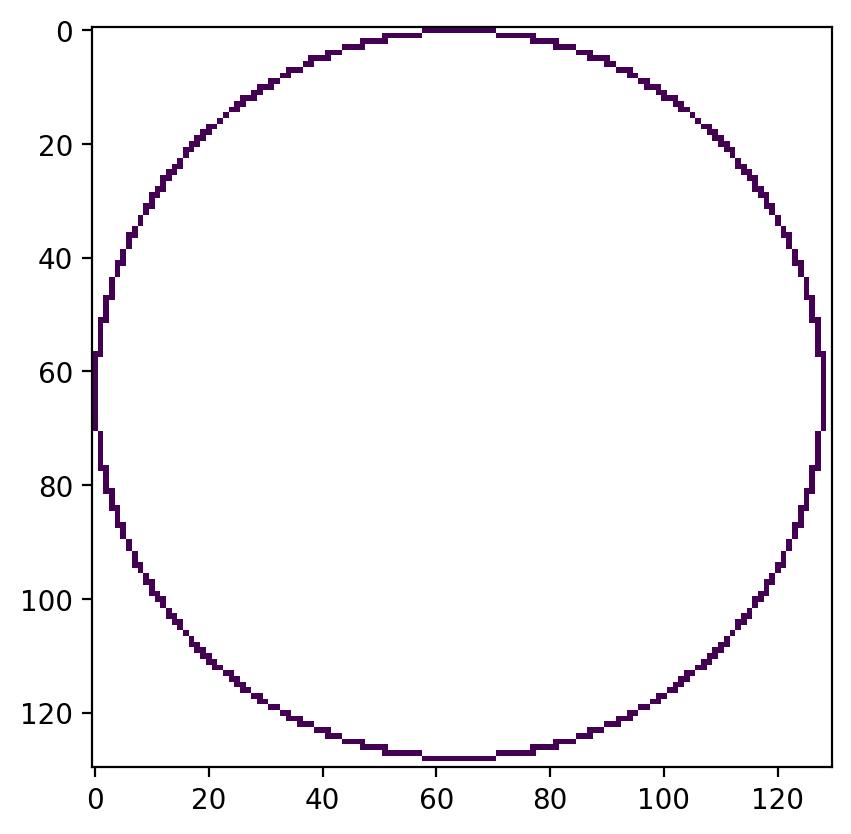

In [35]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][1],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 496.0540000000037
TIME of the SN LC respect to peak 3.9459999999962743
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 10.403379151774853
half_obs_thickness given by dust 0.012782297508764725
carb values
silicate values
FLUX AFTER SURFACE 4.0880243315637194e-29


/tmp/ipykernel_1580259/972133148.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


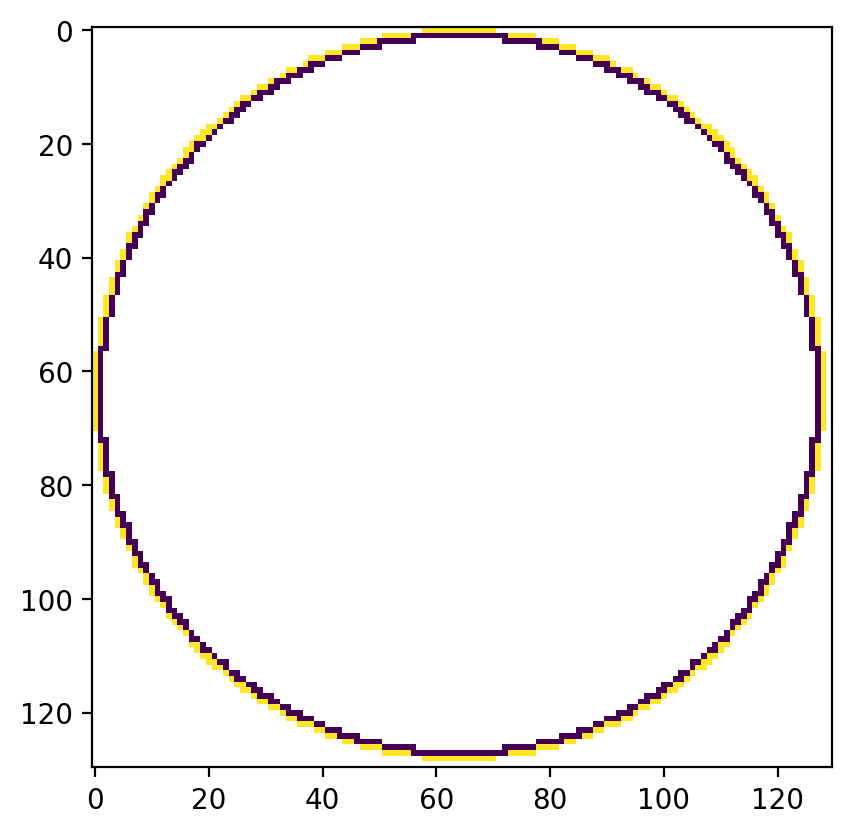

In [36]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][2],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 484.03120000000496
TIME of the SN LC respect to peak 15.968799999995097
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 10.27440762859728
half_obs_thickness given by dust 0.012629057972159633
carb values
silicate values
FLUX AFTER SURFACE 4.0901211674283744e-29


/tmp/ipykernel_1580259/3026172403.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


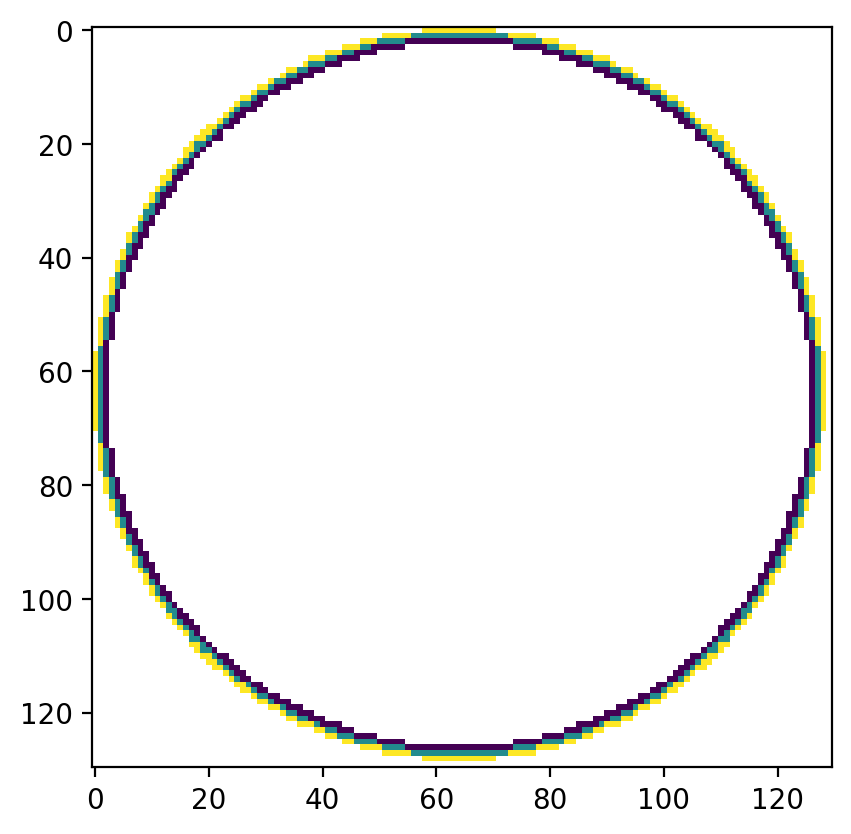

In [37]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][3],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 454.72430000000173
TIME of the SN LC respect to peak 45.27569999999833
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 9.953482489943898
half_obs_thickness given by dust 0.012246937416470313
carb values
silicate values
FLUX AFTER SURFACE 4.095241757300034e-29


/tmp/ipykernel_1580259/1000575273.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


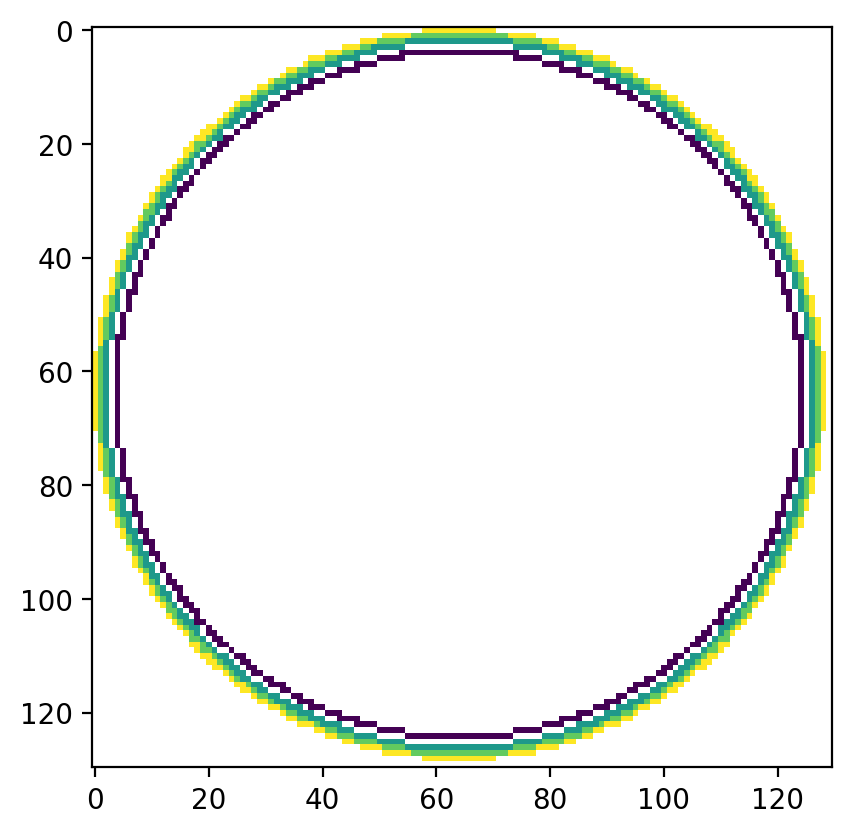

In [38]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][5],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 422.59590000000026
TIME of the SN LC respect to peak 77.40409999999974
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 9.590099753856416
half_obs_thickness given by dust 0.011812900525819469
carb values
silicate values
FLUX AFTER SURFACE 4.100870568884134e-29


/tmp/ipykernel_1580259/1046940641.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


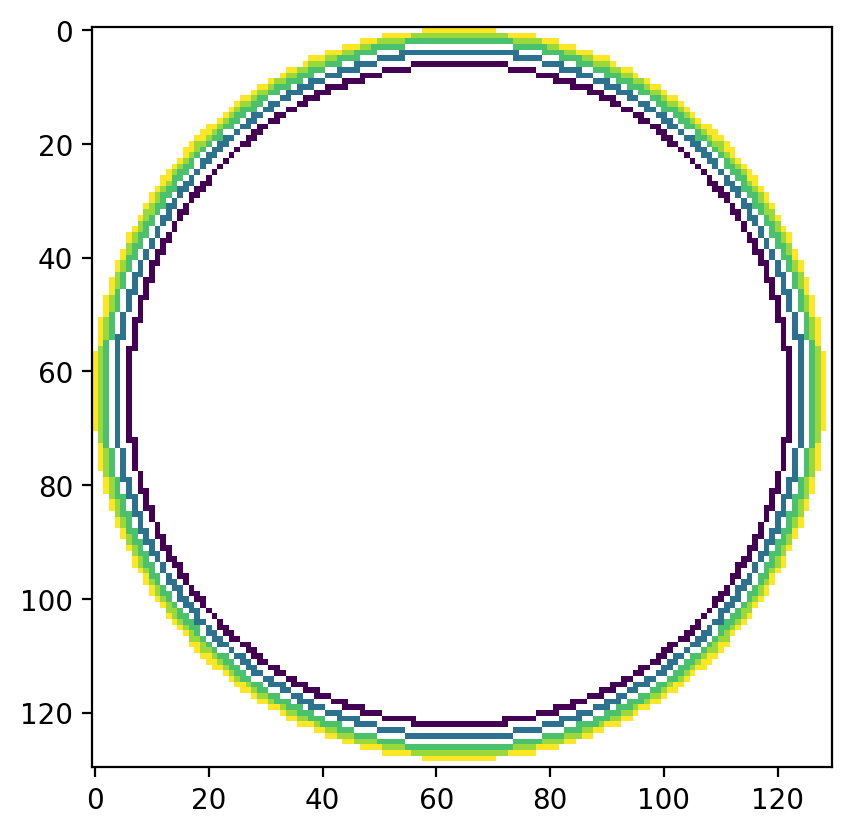

In [39]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][7],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 381.5740000000006
TIME of the SN LC respect to peak 118.42599999999946
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 9.106309863084974
half_obs_thickness given by dust 0.01123287026232401
carb values
silicate values
FLUX AFTER SURFACE 4.1080807770305387e-29


/tmp/ipykernel_1580259/987179638.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


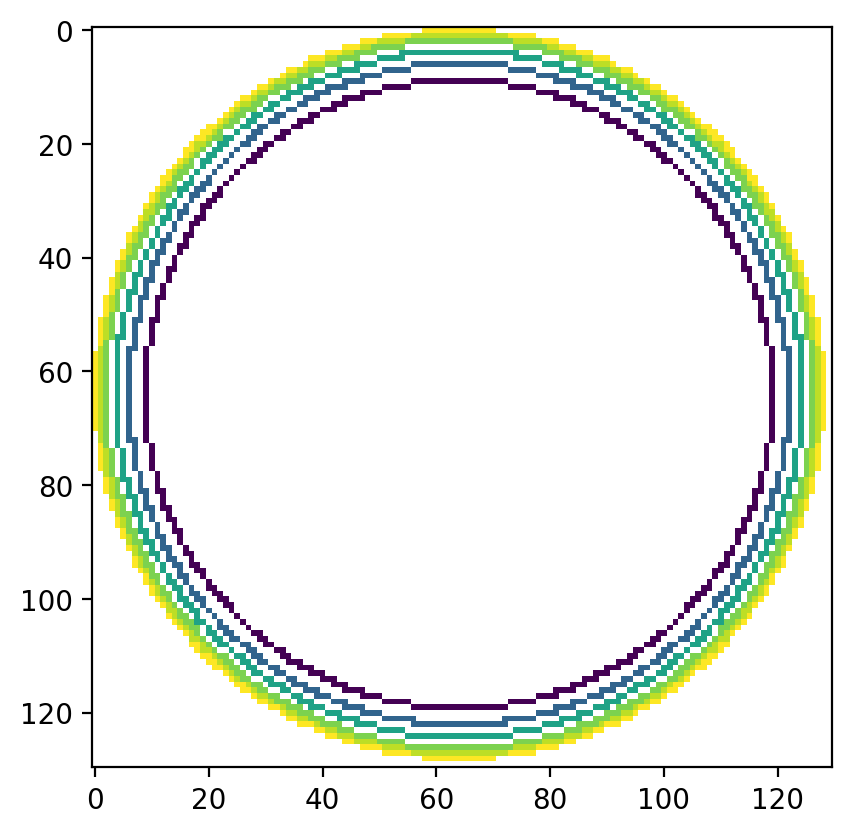

In [40]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][8],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 303.86409999999887
TIME of the SN LC respect to peak 196.13590000000116
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 8.115384894363958
half_obs_thickness given by dust 0.010037479317584946
carb values
silicate values
FLUX AFTER SURFACE 4.121811517233392e-29


/tmp/ipykernel_1580259/2979142975.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


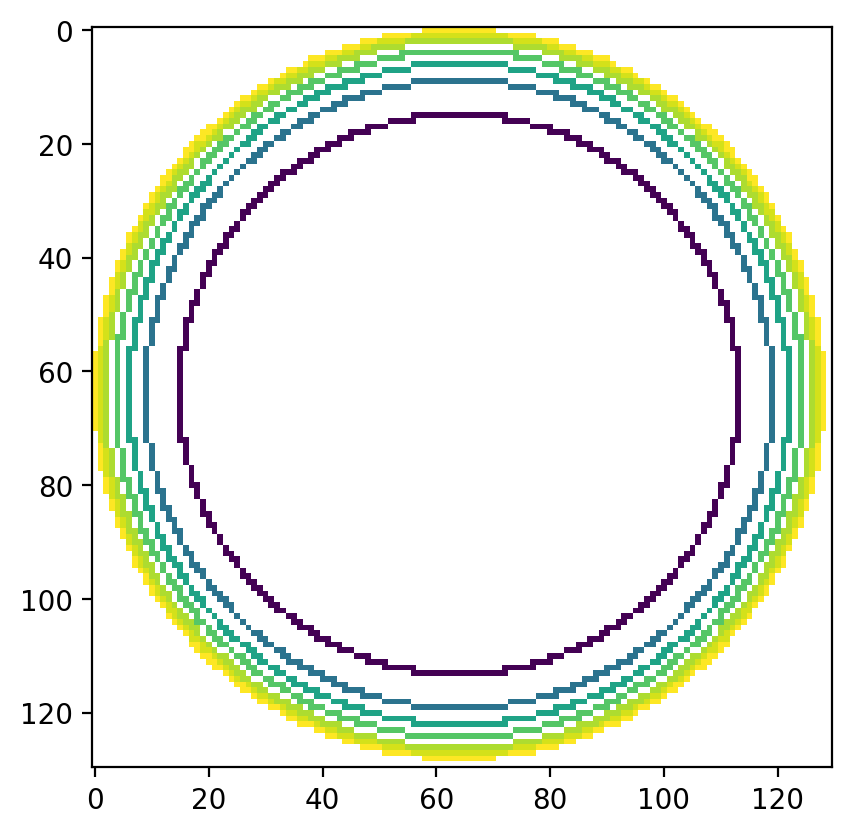

In [41]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][10],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 244.65469999999917
TIME of the SN LC respect to peak 255.34530000000086
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.412385256498134e-16
mean of rho 7.274455338541214
half_obs_thickness given by dust 0.009015866526658395
carb values
silicate values
FLUX AFTER SURFACE 4.132337204501595e-29


/tmp/ipykernel_1580259/540260307.py:14: RuntimeWarning: invalid value encountered in log10
  ax.imshow(-2.5*np.log10(matrix_surface)-48.6)


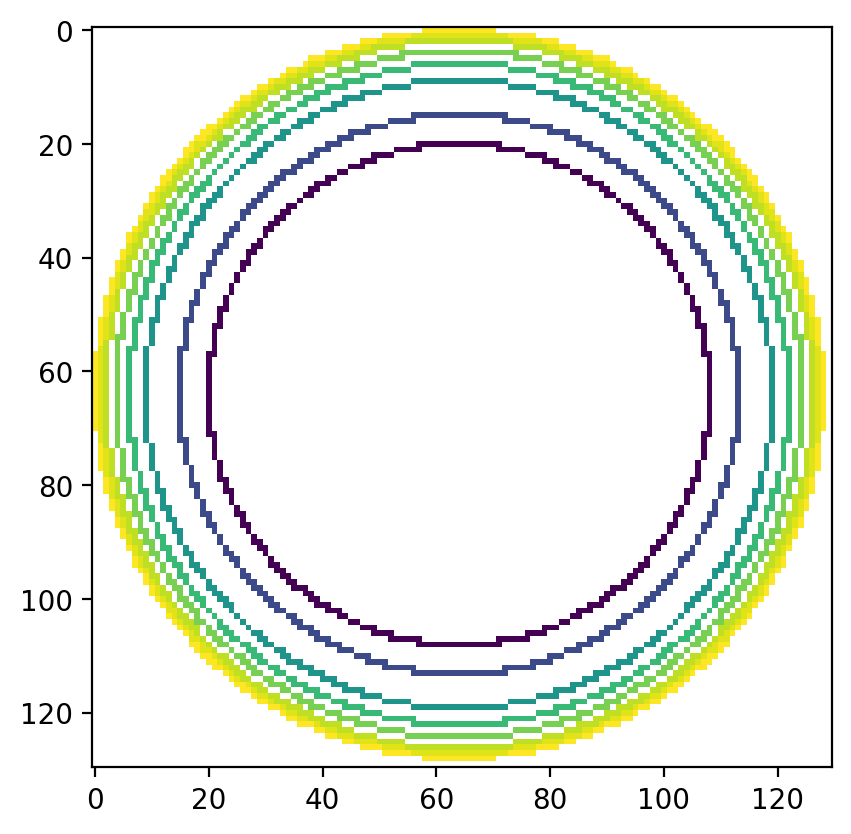

In [42]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][11],
                                                                                                                                              return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'][::40][ij], x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

    
for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]
fig, ax = plt.subplots()
ax.imshow(-2.5*np.log10(matrix_surface)-48.6)
# plt.colorbar()
plt.show()

True
TIME LE elliposid in days 484.03120000000496
TIME of the SN LC respect to peak 15.968799999995097
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 5.671489571383294e-16
mean of rho 10.27440762859728
half_obs_thickness given by dust 0.012629057972159633
carb values
silicate values
FLUX AFTER SURFACE 3.129502682881756e-29
Before angle clipping
Len of z values
0
True
TIME LE elliposid in days 465.0108000000037
TIME of the SN LC respect to peak 34.989199999996345
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 6.116837363414515e-16
mean of rho 10.067217143816785
half_obs_thickness given by dust 0.012382490278160824
carb values
silicate values
FLUX AFTER SURFACE 3.377984816453853e-29
Before angle clipping
Len of z values
0
True

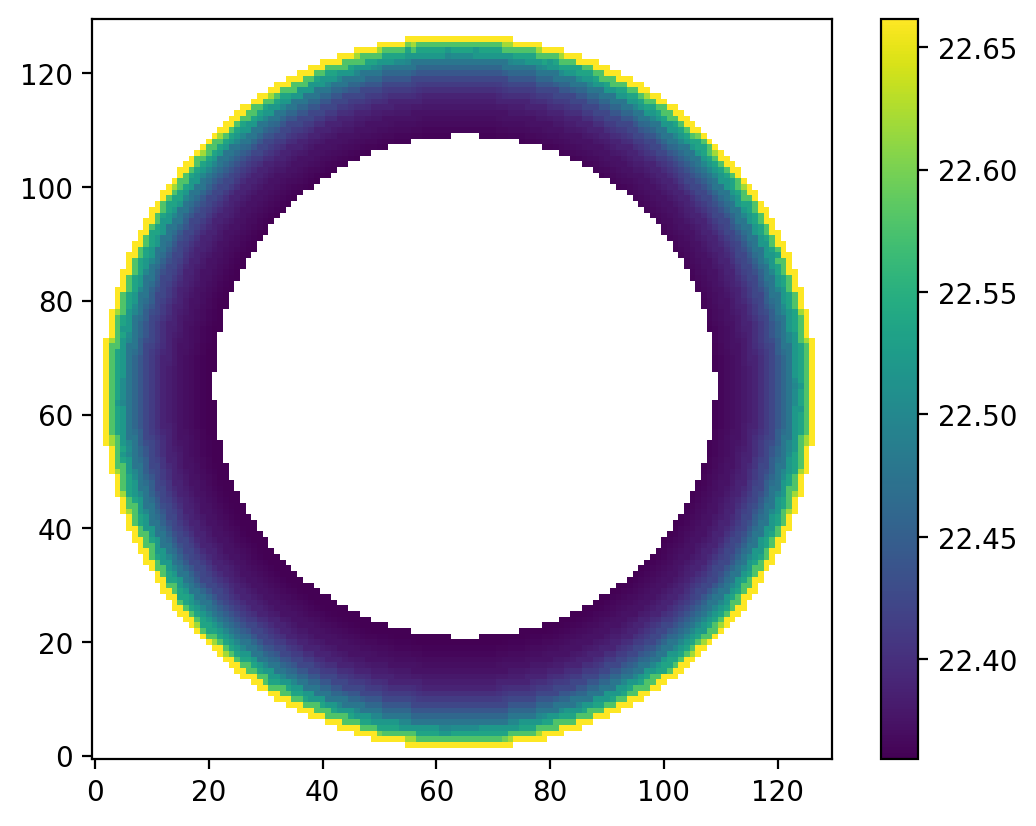